<a href="https://colab.research.google.com/github/A-b-h-i-n-a-V-01/Smart-EV-Charging-Station-Recommendation-System/blob/main/EV_Charging_Station_Recommendation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Smart EV Charging Station Recommendation System using Machine Learning-Based Wait Time Prediction
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as plt

In [ ]:
data = pd.read_csv('/content/EV_Charging_100k.csv')
data.head()

,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-08-02 01:30:00,EV00077,Volta - Los Angeles #17,Volta,Los Angeles,CA,33.911204,-118.153220,Airport,Level 2,...,0.0,clear,4.71,3,none,True,False,1,5,8
1,2025-08-20 01:00:00,EV00010,Volta - San Diego #10,Volta,San Diego,CA,32.859690,-117.067481,Hotel/Hospitality,Level 2,...,0.0,extreme_heat,4.99,2,none,False,False,1,2,8
2,2025-09-07 06:30:00,EV00023,Tesla Supercharger - Chicago #3,Tesla Supercharger,Chicago,IL,41.823295,-87.682445,Urban Center,Tesla DC Fast,...,0.0,partly_cloudy,3.56,3,none,True,False,6,6,9
3,2025-12-08 01:30:00,EV00102,Tesla Supercharger - Seattle #2,Tesla Supercharger,Seattle,WA,47.513232,-122.254816,Suburban,Tesla DC Fast,...,0.0,clear,4.63,1,none,False,False,1,0,12
4,2025-07-03 03:00:00,EV00037,Electrify America - Portland #17,Electrify America,Portland,OR,45.479089,-122.538465,Hotel/Hospitality,Hyper-Fast,...,0.0,clear,4.17,2,none,False,False,3,3,7


In [ ]:
data.columns

Index(['timestamp', 'station_id', 'station_name', 'network', 'city', 'state',
       'latitude', 'longitude', 'location_type', 'charger_type',
       'power_output_kw', 'amenities_nearby', 'ports_total', 'ports_available',
       'ports_occupied', 'ports_out_of_service', 'utilization_rate',
       'station_status', 'estimated_wait_time_mins',
       'avg_session_duration_mins', 'current_price', 'pricing_type',
       'temperature_f', 'precipitation_mm', 'weather_condition',
       'gas_price_per_gallon', 'traffic_congestion_index', 'local_event',
       'is_weekend', 'is_peak_hour', 'hour_of_day', 'day_of_week', 'month'],
      dtype='object')

In [ ]:
data.shape

(100000, 87)

In [ ]:
data.shape

(100000, 87)

In [ ]:
data.dtypes

,0
timestamp,object
station_id,object
station_name,object
network,object
city,object
state,object
latitude,float64
longitude,float64
location_type,object
charger_type,object


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   timestamp                  100000 non-null  object 
 1   station_id                 100000 non-null  object 
 2   station_name               100000 non-null  object 
 3   network                    100000 non-null  object 
 4   city                       100000 non-null  object 
 5   state                      100000 non-null  object 
 6   latitude                   100000 non-null  float64
 7   longitude                  100000 non-null  float64
 8   location_type              100000 non-null  object 
 9   charger_type               100000 non-null  object 
 10  power_output_kw            100000 non-null  float64
 11  amenities_nearby           100000 non-null  object 
 12  ports_total                100000 non-null  int64  
 13  ports_available            100

In [ ]:
data.describe()

,latitude,longitude,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,precipitation_mm,gas_price_per_gallon,traffic_congestion_index,hour_of_day,day_of_week,month
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,37.424664,-101.632594,134.957345,7.332980,4.218730,2.410430,0.703820,0.415494,2.479920,81.665630,0.313993,71.702152,0.572922,3.940977,5.000750,11.497080,2.984730,9.475110
std,5.907052,17.520436,128.706101,4.522615,3.429957,3.350073,2.382086,0.299718,13.364389,72.267456,0.159305,20.871102,2.317220,0.599729,2.481345,6.930318,2.000514,1.706977
min,25.619429,-122.812732,7.200000,2.000000,0.000000,0.000000,0.000000,0.020000,0.000000,21.000000,0.000000,20.100000,0.000000,3.280000,1.000000,0.000000,0.000000,7.000000
25%,33.483556,-117.276641,19.200000,4.000000,2.000000,0.000000,0.000000,0.124000,0.000000,31.000000,0.250000,60.100000,0.000000,3.480000,3.000000,6.000000,1.000000,8.000000
50%,36.302439,-105.023979,100.000000,6.000000,4.000000,1.000000,0.000000,0.399000,0.000000,41.000000,0.340000,74.500000,0.000000,3.660000,5.000000,11.000000,3.000000,9.000000
75%,41.977937,-84.529683,250.000000,8.000000,6.000000,3.000000,0.000000,0.649000,0.000000,141.000000,0.420000,87.500000,0.000000,4.360000,7.000000,17.250000,5.000000,11.000000
max,47.727768,-70.912984,350.000000,24.000000,24.000000,23.000000,24.000000,0.980000,134.000000,251.000000,0.696000,109.900000,49.400000,5.500000,10.000000,23.000000,6.000000,12.000000


In [ ]:
data.isnull().sum()

,0
timestamp,0
station_id,0
station_name,0
network,0
city,0
state,0
latitude,0
longitude,0
location_type,0
charger_type,0


In [ ]:
display(data.tail())

,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
99995,2025-08-11 22:30:00,EV00019,Tesla Supercharger - Boston #19,Tesla Supercharger,Boston,MA,42.232365,-70.913934,Highway Corridor,Tesla DC Fast,...,1.9,light_rain,3.29,6,none,False,False,22,0,8
99996,2025-09-20 07:00:00,EV00116,Tesla Supercharger - Atlanta #16,Tesla Supercharger,Atlanta,GA,33.712281,-84.428807,Workplace,Tesla DC Fast,...,0.0,cloudy,3.52,10,none,True,True,7,5,9
99997,2025-09-19 10:30:00,EV00097,ChargePoint - Austin #17,ChargePoint,Austin,TX,30.178737,-97.869192,Residential,Level 2,...,0.0,extreme_heat,3.54,3,none,False,False,10,4,9
99998,2025-12-08 22:00:00,EV00009,Volta - Austin #9,Volta,Austin,TX,30.171157,-97.870485,Highway Corridor,Level 2,...,0.0,clear,3.57,4,concert,False,False,22,0,12
99999,2025-10-25 14:30:00,EV00083,Shell Recharge - Atlanta #3,Shell Recharge,Atlanta,GA,33.850794,-84.331208,Workplace,DC Fast Charge,...,0.0,partly_cloudy,3.37,6,none,True,False,14,5,10


In [ ]:
data['network'].value_counts()

,count
network,
Electrify America,16004
Volta,14649
Shell Recharge,14120
Tesla Supercharger,14077
Blink,13989
ChargePoint,11287
EVCS,10705
EVgo,5169


In [ ]:
data.dtypes


,0
timestamp,object
station_id,object
station_name,object
network,object
city,object
state,object
latitude,float64
longitude,float64
location_type,object
charger_type,object


In [ ]:
columns_to_drop = ['station_name', 'timestamp', 'latitude', 'longitude']
data.drop(columns=columns_to_drop, inplace=True)

In [ ]:
data.shape

(100000, 29)

In [ ]:
data.columns

Index(['station_id', 'network', 'city', 'state', 'location_type',
       'charger_type', 'power_output_kw', 'amenities_nearby', 'ports_total',
       'ports_available', 'ports_occupied', 'ports_out_of_service',
       'utilization_rate', 'station_status', 'estimated_wait_time_mins',
       'avg_session_duration_mins', 'current_price', 'pricing_type',
       'temperature_f', 'precipitation_mm', 'weather_condition',
       'gas_price_per_gallon', 'traffic_congestion_index', 'local_event',
       'is_weekend', 'is_peak_hour', 'hour_of_day', 'day_of_week', 'month'],
      dtype='object')

In [ ]:
data["charger_type"].value_counts()

,count
charger_type,
DC Fast Charge,46078
Level 2,32502
Tesla DC Fast,14077
Hyper-Fast,7343


### Encoding

In [ ]:
data.dtypes

,0
station_id,object
network,object
city,object
state,object
location_type,object
charger_type,object
power_output_kw,float64
amenities_nearby,object
ports_total,int64
ports_available,int64


In [ ]:
len(data)

100000

In [ ]:
print(f"'station id': {data['station_id'].nunique()} ")
print(f"'network': {data['network'].nunique()} ")
print(f"'city': {data['city'].nunique()} ")
print(f"'state': {data['state'].nunique()} ")
print(f"'location_type': {data['location_type'].nunique()} ")
print(f"'charger_type': {data['charger_type'].nunique()} ")
print(f"'amenities_nearby': {data['amenities_nearby'].nunique()} ")
print(f"'station_status': {data['station_status'].nunique()} ")
print(f"'pricing_type': {data['pricing_type'].nunique()} ")
print(f"'weather_condition': {data['weather_condition'].nunique()} ")
print(f"'local_event': {data['local_event'].nunique()} ")

'station id': 150 
'network': 8 
'city': 15 
'state': 13 
'location_type': 8 
'charger_type': 4 
'amenities_nearby': 123 
'station_status': 4 
'pricing_type': 3 
'weather_condition': 7 
'local_event': 5 


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
station_id_counts = data['station_id'].value_counts()
data['station_id_freq_encoded'] = data['station_id'].map(station_id_counts)
data.drop(columns=['station_id'], inplace=True)
display(data.head())

,network,city,state,location_type,charger_type,power_output_kw,amenities_nearby,ports_total,ports_available,ports_occupied,...,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month,station_id_freq_encoded
0,Volta,Los Angeles,CA,Airport,Level 2,7.2,"Park, Fast Food, Convenience Store",8,7,1,...,clear,4.71,3,none,True,False,1,5,8,586
1,Volta,San Diego,CA,Hotel/Hospitality,Level 2,7.2,"Shopping Mall, WiFi, Restroom, Park, Coffee Shop",4,3,1,...,extreme_heat,4.99,2,none,False,False,1,2,8,656
2,Tesla Supercharger,Chicago,IL,Urban Center,Tesla DC Fast,350.0,"Shopping Mall, Park, Coffee Shop",4,4,0,...,partly_cloudy,3.56,3,none,True,False,6,6,9,676
3,Tesla Supercharger,Seattle,WA,Suburban,Tesla DC Fast,250.0,"WiFi, Fast Food, Hotel",6,5,1,...,clear,4.63,1,none,False,False,1,0,12,699
4,Electrify America,Portland,OR,Hotel/Hospitality,Hyper-Fast,150.0,"Convenience Store, Park, Shopping Mall",4,4,0,...,clear,4.17,2,none,False,False,3,3,7,665


In [ ]:
amenities_nearby_counts = data['amenities_nearby'].value_counts()
data['amenities_nearby_freq_encoded'] = data['amenities_nearby'].map(amenities_nearby_counts)
data.drop(columns=['amenities_nearby'], inplace=True)
display(data.head())

,network,city,state,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,...,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month,station_id_freq_encoded,amenities_nearby_freq_encoded
0,Volta,Los Angeles,CA,Airport,Level 2,7.2,8,7,1,0,...,4.71,3,none,True,False,1,5,8,586,586
1,Volta,San Diego,CA,Hotel/Hospitality,Level 2,7.2,4,3,1,0,...,4.99,2,none,False,False,1,2,8,656,656
2,Tesla Supercharger,Chicago,IL,Urban Center,Tesla DC Fast,350.0,4,4,0,0,...,3.56,3,none,True,False,6,6,9,676,676
3,Tesla Supercharger,Seattle,WA,Suburban,Tesla DC Fast,250.0,6,5,1,0,...,4.63,1,none,False,False,1,0,12,699,699
4,Electrify America,Portland,OR,Hotel/Hospitality,Hyper-Fast,150.0,4,4,0,0,...,4.17,2,none,False,False,3,3,7,665,665


In [ ]:
#One hot encode
data = pd.get_dummies(data, columns=['network'], dtype=int)
data.head()

,city,state,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,...,station_id_freq_encoded,amenities_nearby_freq_encoded,network_Blink,network_ChargePoint,network_EVCS,network_EVgo,network_Electrify America,network_Shell Recharge,network_Tesla Supercharger,network_Volta
0,Los Angeles,CA,Airport,Level 2,7.2,8,7,1,0,0.139,...,586,586,0,0,0,0,0,0,0,1
1,San Diego,CA,Hotel/Hospitality,Level 2,7.2,4,3,1,0,0.256,...,656,656,0,0,0,0,0,0,0,1
2,Chicago,IL,Urban Center,Tesla DC Fast,350.0,4,4,0,0,0.070,...,676,676,0,0,0,0,0,0,1,0
3,Seattle,WA,Suburban,Tesla DC Fast,250.0,6,5,1,0,0.237,...,699,699,0,0,0,0,0,0,1,0
4,Portland,OR,Hotel/Hospitality,Hyper-Fast,150.0,4,4,0,0,0.104,...,665,665,0,0,0,0,1,0,0,0


In [ ]:
data = pd.get_dummies(data, columns=['city'], dtype=int)
display(data.head())

,state,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,...,city_Las Vegas,city_Los Angeles,city_Miami,city_Minneapolis,city_New York,city_Phoenix,city_Portland,city_San Diego,city_San Francisco,city_Seattle
0,CA,Airport,Level 2,7.2,8,7,1,0,0.139,operational,...,0,1,0,0,0,0,0,0,0,0
1,CA,Hotel/Hospitality,Level 2,7.2,4,3,1,0,0.256,operational,...,0,0,0,0,0,0,0,1,0,0
2,IL,Urban Center,Tesla DC Fast,350.0,4,4,0,0,0.070,operational,...,0,0,0,0,0,0,0,0,0,0
3,WA,Suburban,Tesla DC Fast,250.0,6,5,1,0,0.237,operational,...,0,0,0,0,0,0,0,0,0,1
4,OR,Hotel/Hospitality,Hyper-Fast,150.0,4,4,0,0,0.104,operational,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
data = pd.get_dummies(data, columns=['state'], dtype=int)
display(data.head())

,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,estimated_wait_time_mins,...,state_FL,state_GA,state_IL,state_MA,state_MN,state_NV,state_NY,state_OR,state_TX,state_WA
0,Airport,Level 2,7.2,8,7,1,0,0.139,operational,0,...,0,0,0,0,0,0,0,0,0,0
1,Hotel/Hospitality,Level 2,7.2,4,3,1,0,0.256,operational,0,...,0,0,0,0,0,0,0,0,0,0
2,Urban Center,Tesla DC Fast,350.0,4,4,0,0,0.070,operational,0,...,0,0,1,0,0,0,0,0,0,0
3,Suburban,Tesla DC Fast,250.0,6,5,1,0,0.237,operational,0,...,0,0,0,0,0,0,0,0,0,1
4,Hotel/Hospitality,Hyper-Fast,150.0,4,4,0,0,0.104,operational,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
data = pd.get_dummies(data, columns=['location_type'], dtype=int)
display(data.head())

,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,estimated_wait_time_mins,avg_session_duration_mins,...,state_TX,state_WA,location_type_Airport,location_type_Highway Corridor,location_type_Hotel/Hospitality,location_type_Residential,location_type_Shopping Center,location_type_Suburban,location_type_Urban Center,location_type_Workplace
0,Level 2,7.2,8,7,1,0,0.139,operational,0,130,...,0,0,1,0,0,0,0,0,0,0
1,Level 2,7.2,4,3,1,0,0.256,operational,0,220,...,0,0,0,0,1,0,0,0,0,0
2,Tesla DC Fast,350.0,4,4,0,0,0.070,operational,0,43,...,0,0,0,0,0,0,0,0,1,0
3,Tesla DC Fast,250.0,6,5,1,0,0.237,operational,0,40,...,0,1,0,0,0,0,0,1,0,0
4,Hyper-Fast,150.0,4,4,0,0,0.104,operational,0,40,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
data = pd.get_dummies(data, columns=['charger_type'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,estimated_wait_time_mins,avg_session_duration_mins,current_price,...,location_type_Hotel/Hospitality,location_type_Residential,location_type_Shopping Center,location_type_Suburban,location_type_Urban Center,location_type_Workplace,charger_type_DC Fast Charge,charger_type_Hyper-Fast,charger_type_Level 2,charger_type_Tesla DC Fast
0,7.2,8,7,1,0,0.139,operational,0,130,0.000,...,0,0,0,0,0,0,0,0,1,0
1,7.2,4,3,1,0,0.256,operational,0,220,0.000,...,1,0,0,0,0,0,0,0,1,0
2,350.0,4,4,0,0,0.070,operational,0,43,0.300,...,0,0,0,0,1,0,0,0,0,1
3,250.0,6,5,1,0,0.237,operational,0,40,0.310,...,0,0,0,1,0,0,0,0,0,1
4,150.0,4,4,0,0,0.104,operational,0,40,0.416,...,1,0,0,0,0,0,0,1,0,0


In [ ]:
data = pd.get_dummies(data, columns=['station_status'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,pricing_type,...,location_type_Urban Center,location_type_Workplace,charger_type_DC Fast Charge,charger_type_Hyper-Fast,charger_type_Level 2,charger_type_Tesla DC Fast,station_status_offline,station_status_operational,station_status_partial_outage,station_status_under_maintenance
0,7.2,8,7,1,0,0.139,0,130,0.000,free,...,0,0,0,0,1,0,0,1,0,0
1,7.2,4,3,1,0,0.256,0,220,0.000,free,...,0,0,0,0,1,0,0,1,0,0
2,350.0,4,4,0,0,0.070,0,43,0.300,per_kwh,...,1,0,0,0,0,1,0,1,0,0
3,250.0,6,5,1,0,0.237,0,40,0.310,per_kwh,...,0,0,0,0,0,1,0,1,0,0
4,150.0,4,4,0,0,0.104,0,40,0.416,per_kwh,...,0,0,0,1,0,0,0,1,0,0


In [ ]:
data = pd.get_dummies(data, columns=['pricing_type'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,...,charger_type_Hyper-Fast,charger_type_Level 2,charger_type_Tesla DC Fast,station_status_offline,station_status_operational,station_status_partial_outage,station_status_under_maintenance,pricing_type_free,pricing_type_per_kwh,pricing_type_per_minute
0,7.2,8,7,1,0,0.139,0,130,0.000,88.4,...,0,1,0,0,1,0,0,1,0,0
1,7.2,4,3,1,0,0.256,0,220,0.000,100.0,...,0,1,0,0,1,0,0,1,0,0
2,350.0,4,4,0,0,0.070,0,43,0.300,83.6,...,0,0,1,0,1,0,0,0,1,0
3,250.0,6,5,1,0,0.237,0,40,0.310,33.0,...,0,0,1,0,1,0,0,0,1,0
4,150.0,4,4,0,0,0.104,0,40,0.416,93.1,...,1,0,0,0,1,0,0,0,1,0


In [ ]:
data = pd.get_dummies(data, columns=['weather_condition'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,...,pricing_type_free,pricing_type_per_kwh,pricing_type_per_minute,weather_condition_clear,weather_condition_cloudy,weather_condition_extreme_heat,weather_condition_freezing,weather_condition_heavy_rain,weather_condition_light_rain,weather_condition_partly_cloudy
0,7.2,8,7,1,0,0.139,0,130,0.000,88.4,...,1,0,0,1,0,0,0,0,0,0
1,7.2,4,3,1,0,0.256,0,220,0.000,100.0,...,1,0,0,0,0,1,0,0,0,0
2,350.0,4,4,0,0,0.070,0,43,0.300,83.6,...,0,1,0,0,0,0,0,0,0,1
3,250.0,6,5,1,0,0.237,0,40,0.310,33.0,...,0,1,0,1,0,0,0,0,0,0
4,150.0,4,4,0,0,0.104,0,40,0.416,93.1,...,0,1,0,1,0,0,0,0,0,0


In [ ]:
data = pd.get_dummies(data, columns=['local_event'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,...,weather_condition_extreme_heat,weather_condition_freezing,weather_condition_heavy_rain,weather_condition_light_rain,weather_condition_partly_cloudy,local_event_concert,local_event_conference,local_event_festival,local_event_none,local_event_sports_game
0,7.2,8,7,1,0,0.139,0,130,0.000,88.4,...,0,0,0,0,0,0,0,0,1,0
1,7.2,4,3,1,0,0.256,0,220,0.000,100.0,...,1,0,0,0,0,0,0,0,1,0
2,350.0,4,4,0,0,0.070,0,43,0.300,83.6,...,0,0,0,0,1,0,0,0,1,0
3,250.0,6,5,1,0,0.237,0,40,0.310,33.0,...,0,0,0,0,0,0,0,0,1,0
4,150.0,4,4,0,0,0.104,0,40,0.416,93.1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
data.shape

(100000, 87)

In [ ]:
data.columns

Index(['power_output_kw', 'ports_total', 'ports_available', 'ports_occupied',
       'ports_out_of_service', 'utilization_rate', 'estimated_wait_time_mins',
       'avg_session_duration_mins', 'current_price', 'temperature_f',
       'precipitation_mm', 'gas_price_per_gallon', 'traffic_congestion_index',
       'is_weekend', 'is_peak_hour', 'hour_of_day', 'day_of_week', 'month',
       'station_id_freq_encoded', 'amenities_nearby_freq_encoded',
       'network_Blink', 'network_ChargePoint', 'network_EVCS', 'network_EVgo',
       'network_Electrify America', 'network_Shell Recharge',
       'network_Tesla Supercharger', 'network_Volta', 'city_Atlanta',
       'city_Austin', 'city_Boston', 'city_Chicago', 'city_Denver',
       'city_Las Vegas', 'city_Los Angeles', 'city_Miami', 'city_Minneapolis',
       'city_New York', 'city_Phoenix', 'city_Portland', 'city_San Diego',
       'city_San Francisco', 'city_Seattle', 'state_AZ', 'state_CA',
       'state_CO', 'state_FL', 'state_GA', 'state

Finding Outlier

<Axes: ylabel='power_output_kw'>

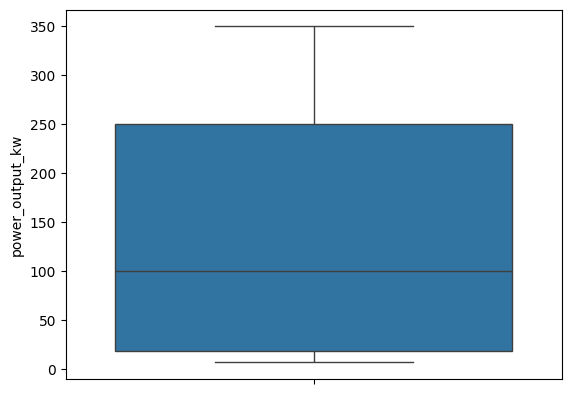

In [ ]:
sns.boxplot(data['power_output_kw'])

<Axes: ylabel='ports_total'>

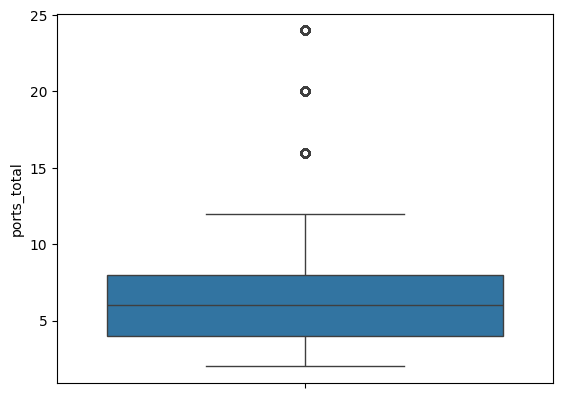

In [ ]:
sns.boxplot(data['ports_total'])

<Axes: ylabel='ports_available'>

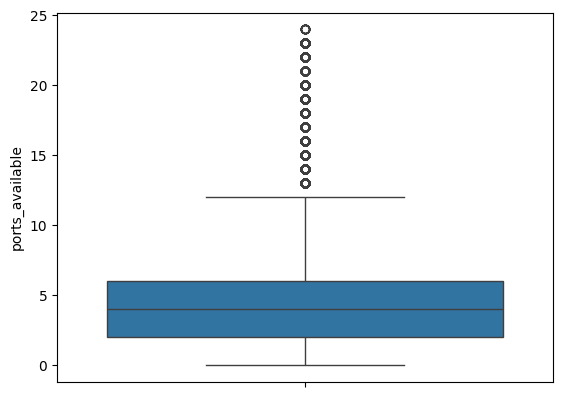

In [ ]:
sns.boxplot(data['ports_available'])

<Axes: ylabel='ports_occupied'>

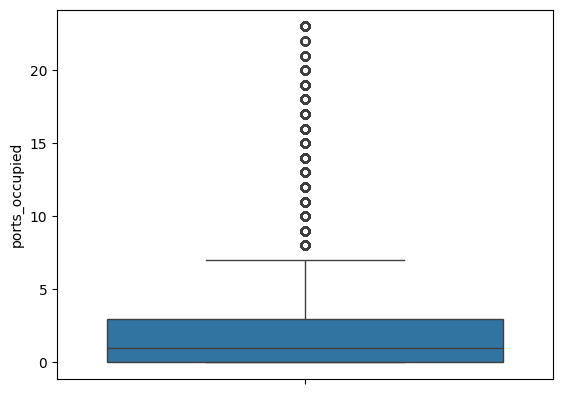

In [ ]:
sns.boxplot(data['ports_occupied'])

<Axes: ylabel='ports_out_of_service'>

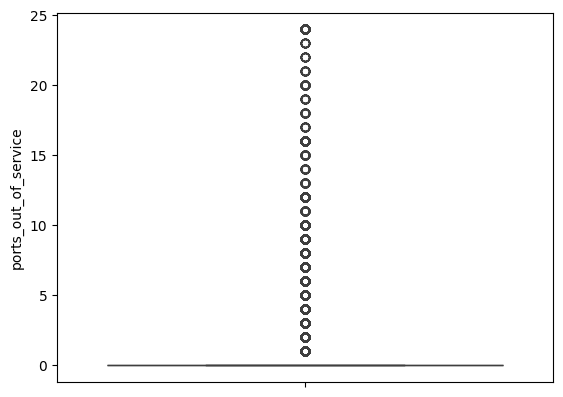

In [ ]:
sns.boxplot(data['ports_out_of_service'])

<Axes: ylabel='utilization_rate'>

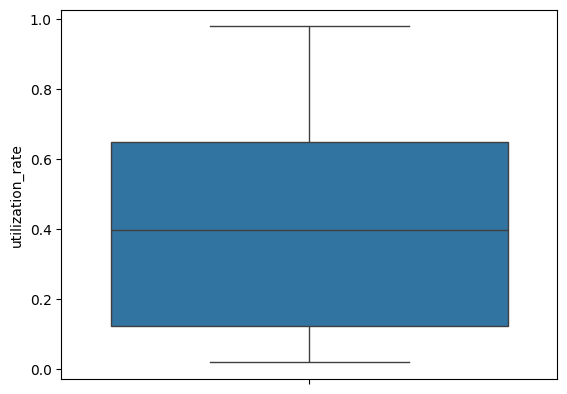

In [ ]:
sns.boxplot(data['utilization_rate'])

<Axes: ylabel='estimated_wait_time_mins'>

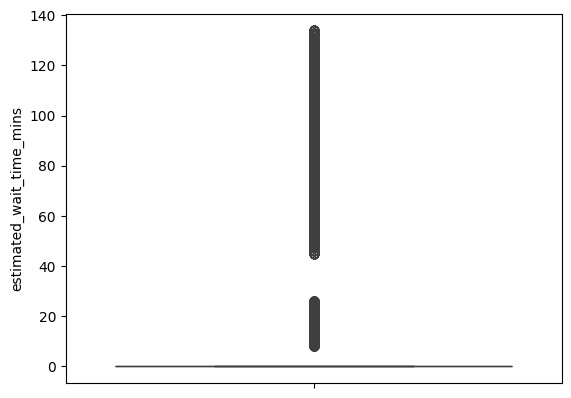

In [ ]:
sns.boxplot(data['estimated_wait_time_mins'])

<Axes: ylabel='avg_session_duration_mins'>

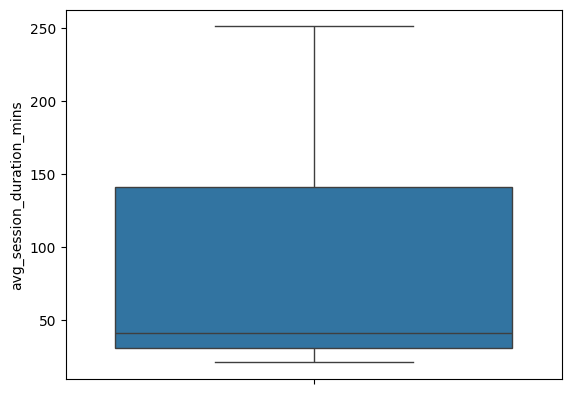

In [ ]:
sns.boxplot(data['avg_session_duration_mins'])

<Axes: ylabel='current_price'>

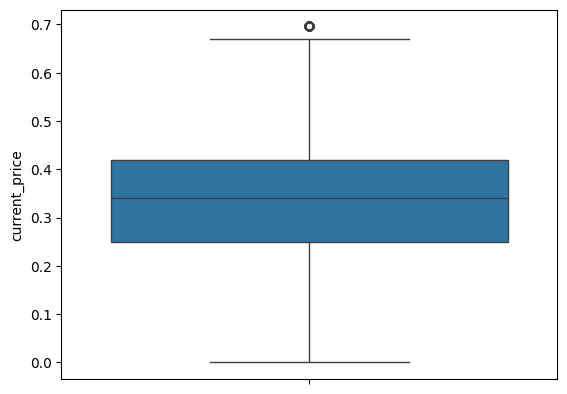

In [ ]:
sns.boxplot(data['current_price'])

<Axes: ylabel='temperature_f'>

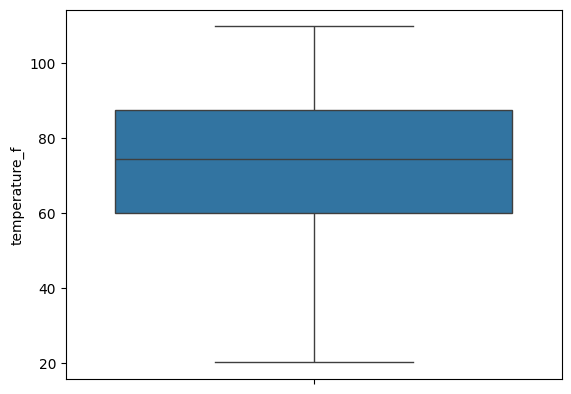

In [ ]:
sns.boxplot(data['temperature_f'])

<Axes: ylabel='precipitation_mm'>

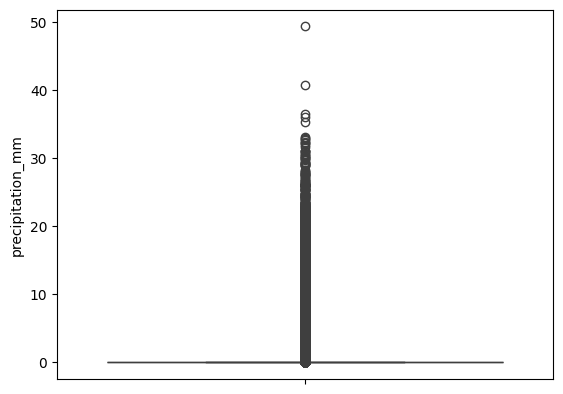

In [ ]:
sns.boxplot(data['precipitation_mm'])

<Axes: ylabel='gas_price_per_gallon'>

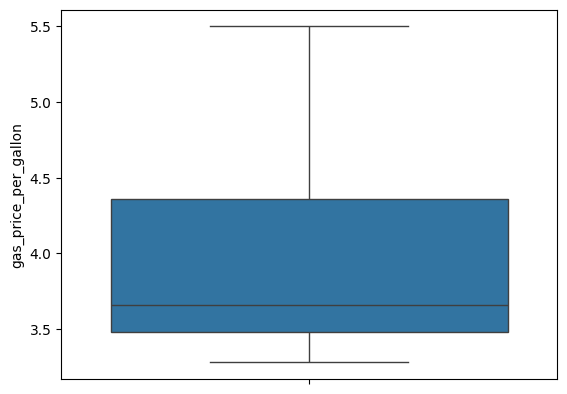

In [ ]:
sns.boxplot(data['gas_price_per_gallon'])

<Axes: ylabel='traffic_congestion_index'>

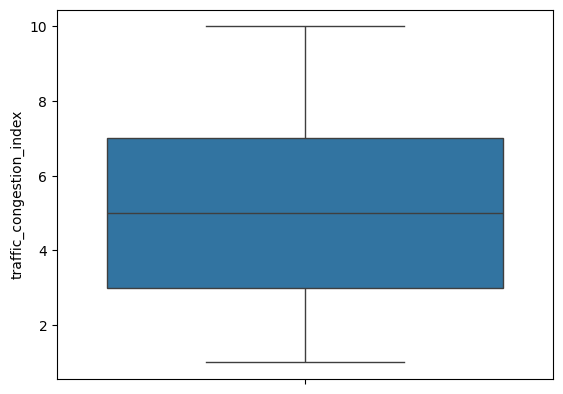

In [ ]:
sns.boxplot(data['traffic_congestion_index'])

<Axes: ylabel='hour_of_day'>

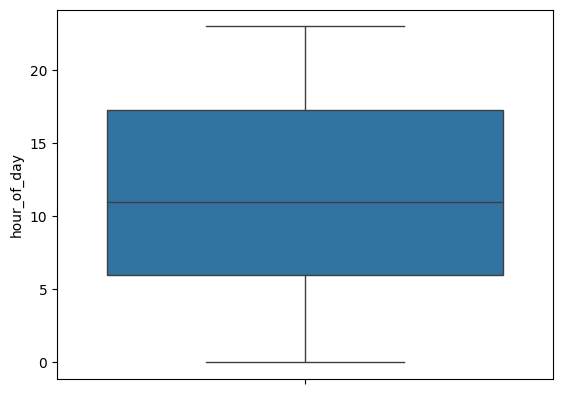

In [ ]:
sns.boxplot(data['hour_of_day'])

<Axes: ylabel='day_of_week'>

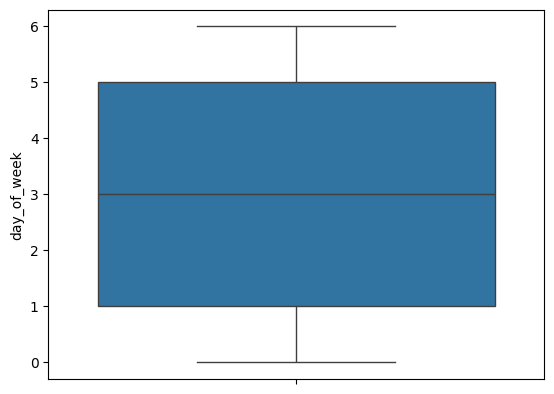

In [ ]:
sns.boxplot(data['day_of_week'])

<Axes: ylabel='month'>

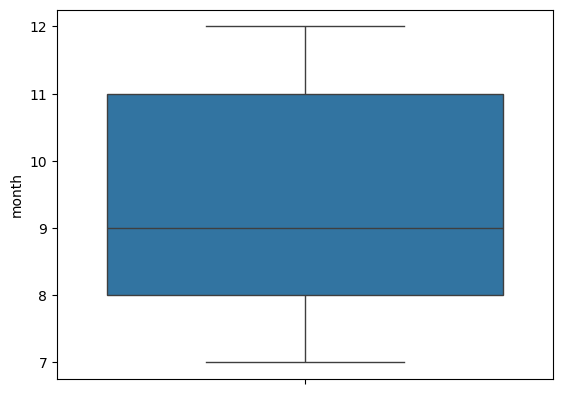

In [ ]:
sns.boxplot(data['month'])

<Axes: ylabel='day_of_week'>

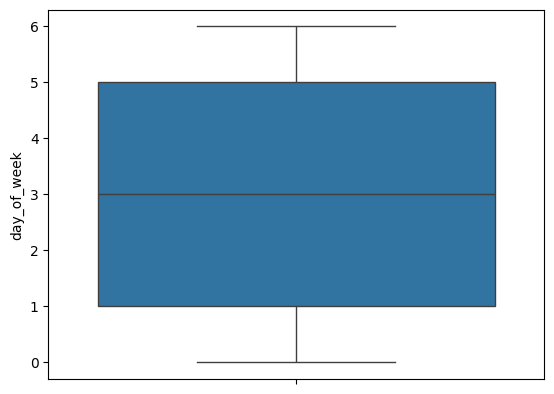

In [ ]:
sns.boxplot(data['day_of_week'])

<Axes: ylabel='month'>

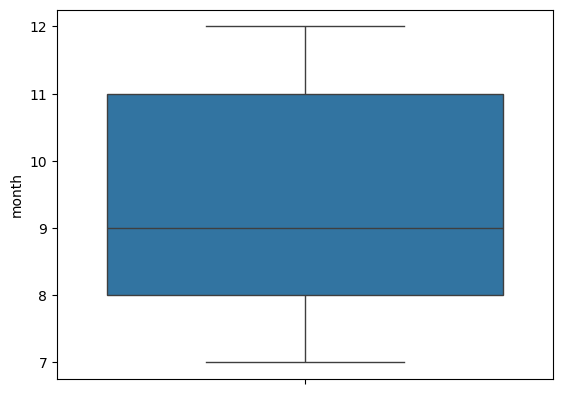

In [ ]:
sns.boxplot(data['month'])

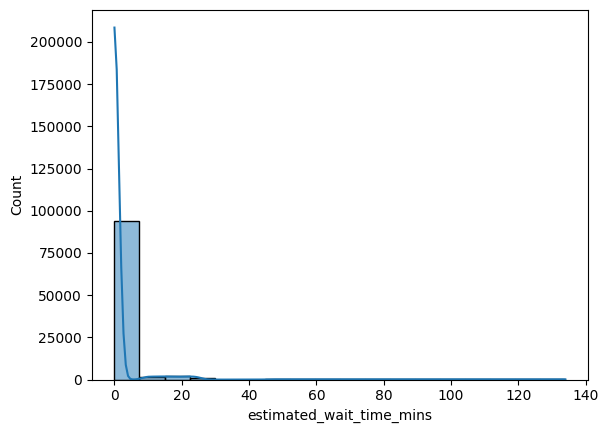

In [ ]:
import matplotlib.pyplot as plt
sns.histplot(data['estimated_wait_time_mins'], kde=True)
plt.show()

In [ ]:
data.dtypes

,0
power_output_kw,float64
ports_total,int64
ports_available,int64
ports_occupied,int64
ports_out_of_service,int64
...,...
local_event_concert,int64
local_event_conference,int64
local_event_festival,int64
local_event_none,int64


In [ ]:
data.select_dtypes(include='object').columns

Index([], dtype='object')

## Train Test Split Data

In [ ]:
X = data.drop('estimated_wait_time_mins', axis=1)

y = data['estimated_wait_time_mins']

In [ ]:
print(X.shape)
print(y.shape)

(100000, 86)
(100000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 86)
(20000, 86)
(80000,)
(20000,)


### Training a Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print(f"Training R-squared score: {linear_model.score(X_train, y_train):}")
print(f"Testing R-squared score: {linear_model.score(X_test, y_test):}")


Training R-squared score: 0.45190726059384045
Testing R-squared score: 0.45844675845895333


In [ ]:
#DecisionTree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

print(f"Training R-squared score: {tree_model.score(X_train, y_train):}")
print(f"Testing R-squared score: {tree_model.score(X_test, y_test):}")

Training R-squared score: 1.0
Testing R-squared score: 0.8200812569657746
